In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

DATI_TB = Path("..") / "dati_tensorboard"
SEMI = [0, 1, 2, 3, 4]
EPOCA_SVOLTA = 170  # oltre questa epoca l'AUC smette di saturare e comincia a scendere


def carica_curve(sottocartella, semi=SEMI):
    "Legge i json esportati da tensorboard per ogni seme: [wall_time, step, value]."
    curve = {}
    for i in semi:
        with open(DATI_TB / sottocartella / f"riproduzione_2.6M_deep_low_seme{i}.json") as f:
            dati = json.load(f)
        epoche = [riga[1] for riga in dati]
        valori = [riga[2] for riga in dati]
        curve[i] = (epoche, valori)
    return curve


def grafico_curve(curve, ylabel, titolo, epoca_svolta=EPOCA_SVOLTA, etichetta="seme", evidenzia=None, colori=None):
    fig, ax = plt.subplots(figsize=(8, 5))

    for i, (epoche, valori) in curve.items():
        if i == evidenzia:
            continue
        if evidenzia is not None:
            ax.plot(epoche, valori, linewidth=1.3, color="gray", alpha=0.5, label=f"{etichetta} {i}")
        else:
            colore = colori.get(i) if colori else None
            ax.plot(epoche, valori, linewidth=1.3, color=colore, label=f"{etichetta} {i}")

    if evidenzia is not None:
        epoche, valori = curve[evidenzia]
        ax.plot(epoche, valori, linewidth=2.5, color="crimson", zorder=5,
                label=f"{etichetta} {evidenzia}")

    if epoca_svolta is not None:
        ax.axvline(epoca_svolta, color="black", linestyle="--", linewidth=1.2,
                   label=f"epoca {epoca_svolta}")

    ax.set_xlabel("epoca")
    ax.set_ylabel(ylabel)
    ax.set_title(titolo)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()

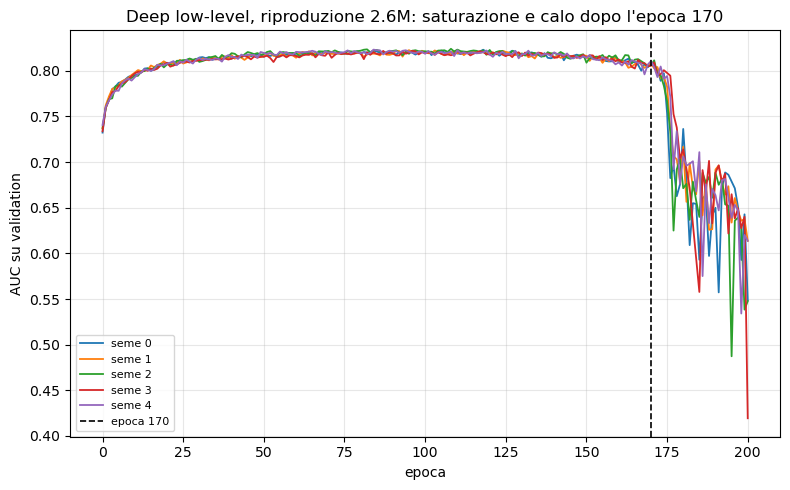

In [2]:
# AUC su validation
curve_auc = carica_curve("AUC_2.6M")
grafico_curve(curve_auc, "AUC su validation",
              "Deep low-level, riproduzione 2.6M: saturazione e calo dopo l'epoca 170")

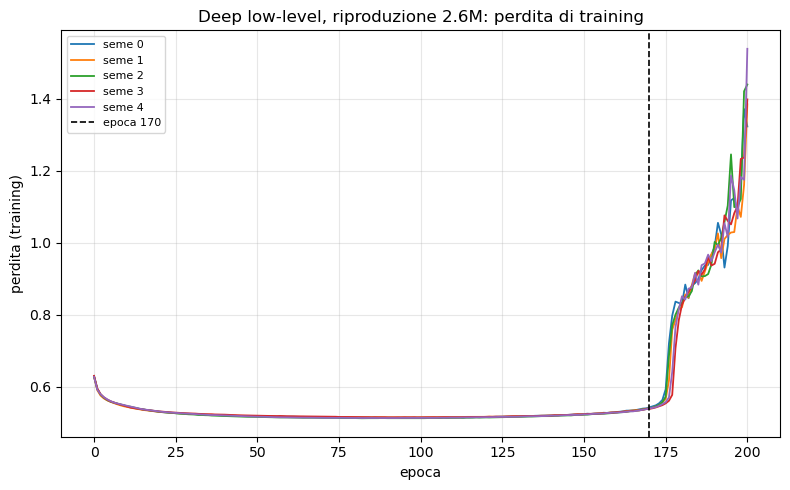

In [3]:
# perdita di training
curve_perdita_train = carica_curve("Perdita_2.6M")
grafico_curve(curve_perdita_train, "perdita (training)",
              "Deep low-level, riproduzione 2.6M: perdita di training")

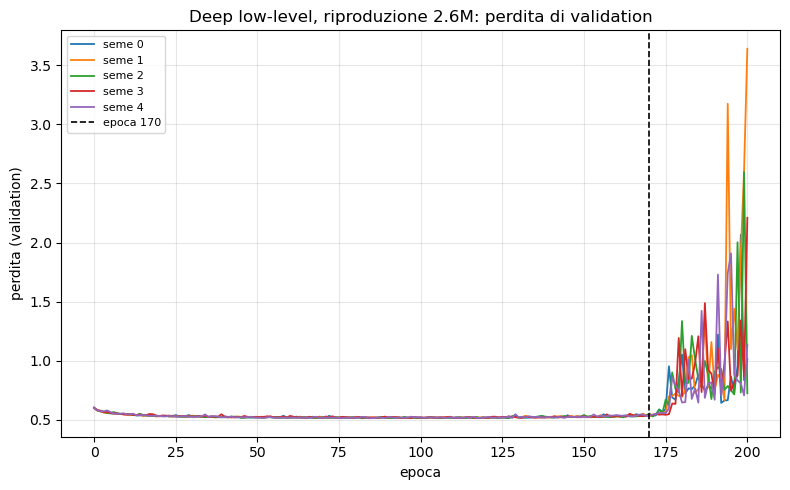

In [4]:
# perdita di validation
curve_perdita_val = carica_curve("val_perdita_2.6M")
grafico_curve(curve_perdita_val, "perdita (validation)",
              "Deep low-level, riproduzione 2.6M: perdita di validation")

In [5]:
# riproduzione completa: deep e shallow, tre feature set, grafici accoppiati
MODELLI = ["shallow", "deep"]
FEATURE_SETS = ["low", "high", "complete"]


def carica_curva_riproduzione(sottocartella, modello, feature_set, seme=0):
    percorso = DATI_TB / sottocartella / f"riproduzione_{modello}_{feature_set}_seme{seme}.json"
    with open(percorso) as f:
        dati = json.load(f)
    epoche = [riga[1] for riga in dati]
    valori = [riga[2] for riga in dati]
    return epoche, valori


def grafico_accoppiato(sottocartella, ylabel, titolo):
    "Un grafico per la rete shallow e uno per la rete profonda, affiancati."
    fig, assi = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    for ax, modello, sottotitolo in zip(assi, MODELLI, ["rete shallow", "rete profonda"]):
        for fs in FEATURE_SETS:
            epoche, valori = carica_curva_riproduzione(sottocartella, modello, fs)
            ax.plot(epoche, valori, linewidth=1.3, label=fs)
        ax.set_xlabel("epoca")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
        ax.set_title(sottotitolo)

    assi[0].set_ylabel(ylabel)
    fig.suptitle(titolo)
    fig.tight_layout()
    plt.show()

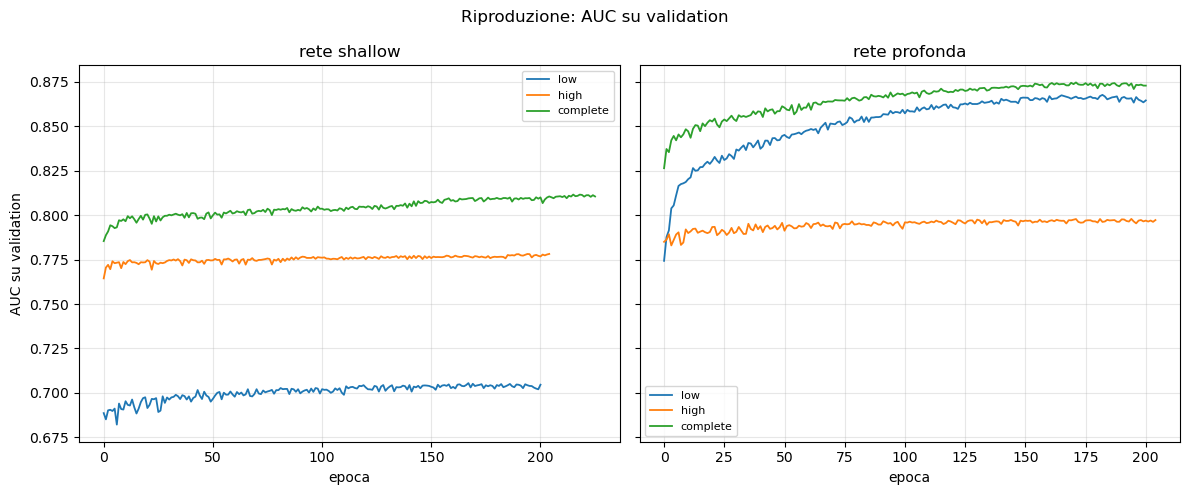

In [6]:
grafico_accoppiato("riproduzione_AUC", "AUC su validation",
                    "Riproduzione: AUC su validation")

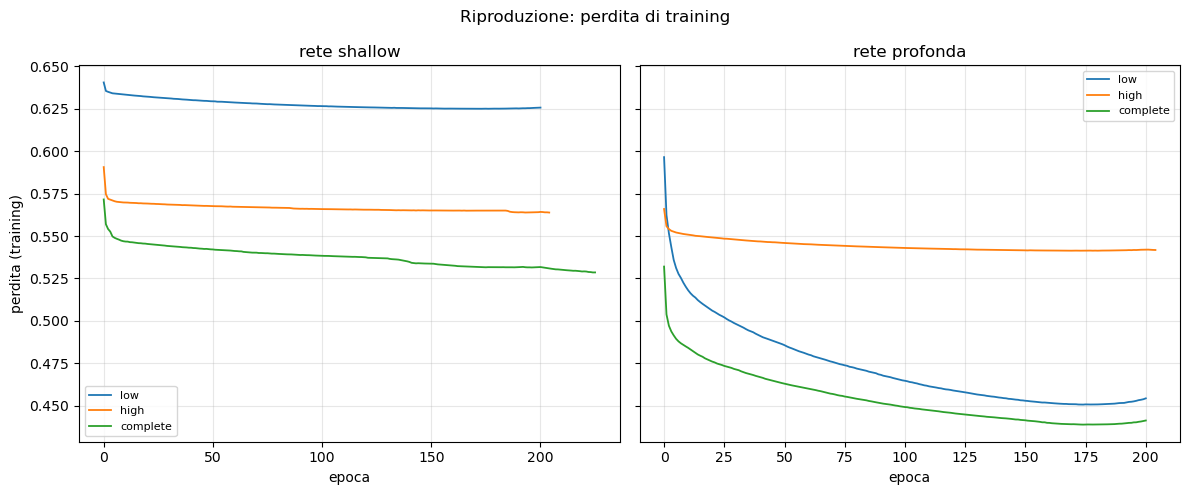

In [7]:
grafico_accoppiato("riproduzione_perdita_train", "perdita (training)",
                    "Riproduzione: perdita di training")

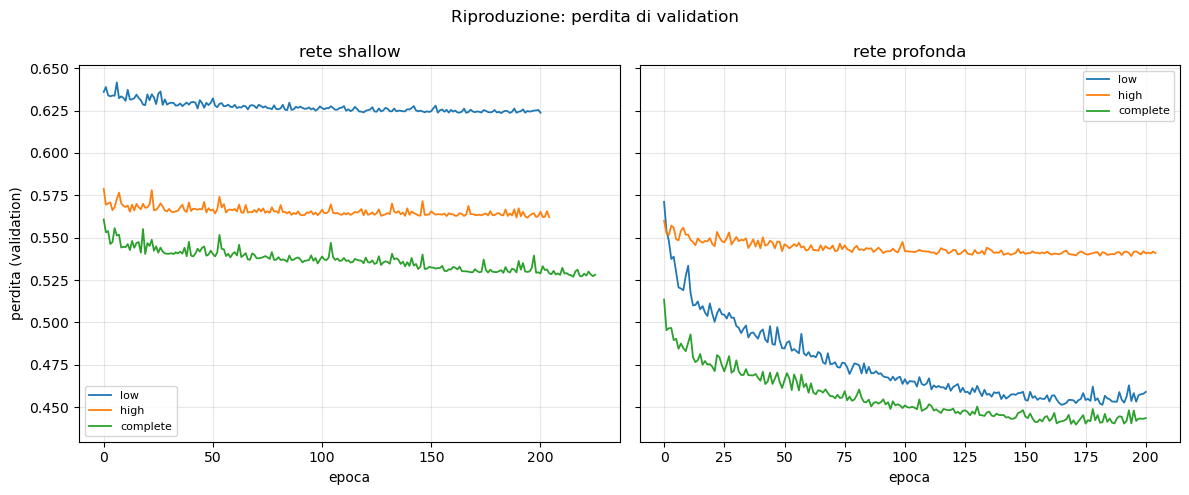

In [8]:
grafico_accoppiato("riproduzione_perdita_validation", "perdita (validation)",
                    "Riproduzione: perdita di validation")

In [9]:
import json, pandas as pd

with open("../results_small/ottimizzazione_low_1000k_batch100_arch.json") as f:
    d = json.load(f)

df = pd.DataFrame(d["tentativi"]).sort_values("auc", ascending=False)
print(df[["tentativo","n_strati","n_unita","lr","weight_decay","auc"]].head(5))

    tentativo  n_strati  n_unita        lr  weight_decay       auc
5           6         7      700  0.002458      0.009849  0.835275
16         17         4      100  0.000563      0.001992  0.815219
8           9         7      200  0.002686      0.000102  0.810988
3           4         7      400  0.000809      0.004338  0.810183
1           2         3      300  0.001373      0.002035  0.809818


In [10]:
import json, pandas as pd

with open("../results_small/ottimizzazione_low_1000k_batch100.json") as f:
    d = json.load(f)

df = pd.DataFrame(d["tentativi"]).sort_values("auc", ascending=False)
print(df[["tentativo","lr","weight_decay","auc"]].head(5))

    tentativo        lr  weight_decay       auc
17         18  0.002100      0.009757  0.837116
5           6  0.001760      0.009849  0.833906
13         14  0.000965      0.008995  0.829805
10         11  0.002883      0.009815  0.825132
24         25  0.002371      0.003224  0.823304


In [11]:
# ottimizzazione iperparametri: curve dei singoli tentativi
def carica_curve_tentativi(sottocartella, prefisso, tentativi):
    "Legge i json esportati da tensorboard per ogni tentativo: [wall_time, step, value]."
    curve = {}
    for t in tentativi:
        with open(DATI_TB / sottocartella / f"{prefisso}_tentativo{t:03d}.json") as f:
            dati = json.load(f)
        epoche = [riga[1] for riga in dati]
        valori = [riga[2] for riga in dati]
        curve[t] = (epoche, valori)
    return curve

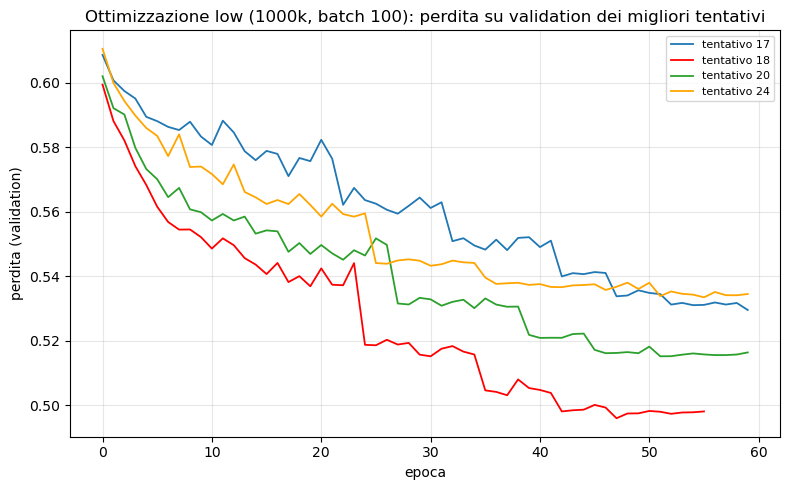

In [12]:
# ricerca 1000k/batch100: perdita di training dei migliori tentativi
curve_ottim_low = carica_curve_tentativi("ottimizzazione1", "ottimizzazione_low", [17, 18, 20, 24])
grafico_curve(curve_ottim_low, "perdita (validation)",
              "Ottimizzazione low (1000k, batch 100): perdita su validation dei migliori tentativi",
              epoca_svolta=None, etichetta="tentativo",
              colori={17: "tab:blue", 18: "red", 20: "tab:green", 24: "orange"})

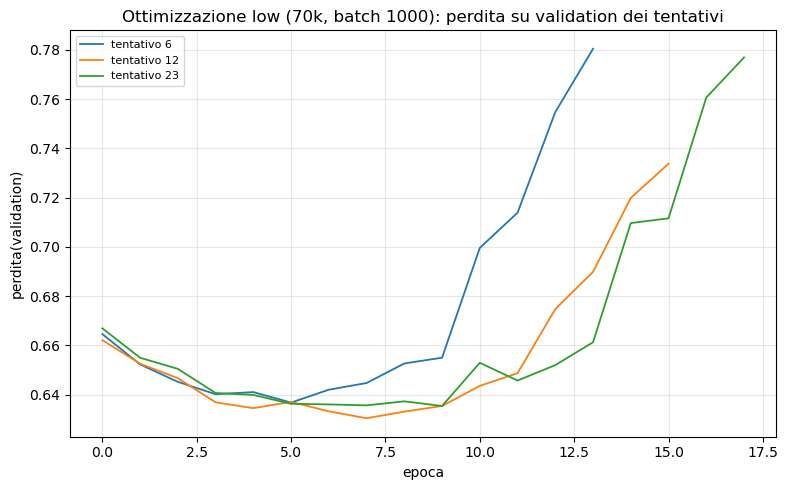

In [13]:
# ricerca 70k/batch1000: AUC su validation dei tentativi
curve_ottim_70k = carica_curve_tentativi("ottimizzazione1", "ottimizzazione_70k_batch1000_low", [6, 12, 23])
grafico_curve(curve_ottim_70k, "perdita(validation)",
              "Ottimizzazione low (70k, batch 1000): perdita su validation dei tentativi",
              epoca_svolta=None, etichetta="tentativo")

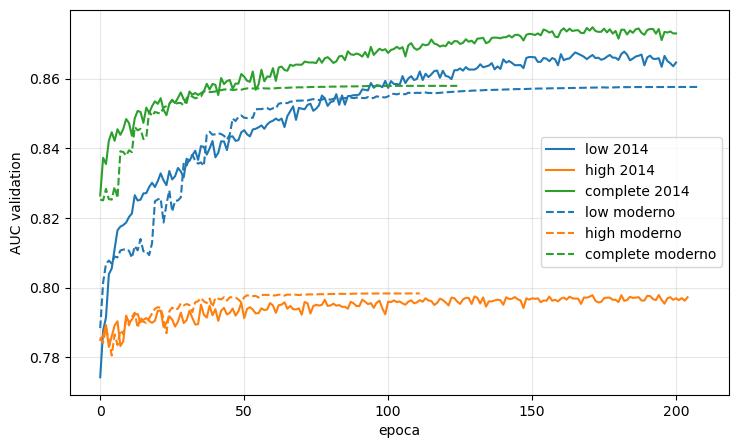

In [14]:
import json, matplotlib.pyplot as plt

COLORI_FS = {"low": "tab:blue", "high": "tab:orange", "complete": "tab:green"}

fig, ax = plt.subplots(figsize=(8.5,5))
for stack, cart in [("2014","riproduzione"), ("moderno","moderno")]:
    for fs in ["low","high","complete"]:
        with open(f"../results/{cart}/deep_{fs}_seme0_storia.json") as f:
            s = json.load(f)
        stile = "-" if stack=="2014" else "--"
        ax.plot(s["auc_val"], stile, color=COLORI_FS[fs], label=f"{fs} {stack}")
ax.set_xlabel("epoca"); ax.set_ylabel("AUC validation")
ax.legend(); ax.grid(alpha=0.3)